In [1]:
!pip install ultralytics --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 110.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 120.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 32.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 15.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!pip install "numpy<2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 110.3 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.15.3 which is incompatible.
datasets 4.1.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires google-auth==2.38.

In [3]:
import numpy as np
import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import yaml

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
import kagglehub

path = kagglehub.dataset_download("saathvik16/bdd100k-object-dection-with-yolo-format-labels")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/bdd100k-object-dection-with-yolo-format-labels


In [5]:
data_yaml_content = """
train: /kaggle/input/bdd100k-object-dection-with-yolo-format-labels/100k-dataset/train/images
val: /kaggle/input/bdd100k-object-dection-with-yolo-format-labels/100k-dataset/val/images
test: /kaggle/input/bdd100k-object-dection-with-yolo-format-labels/100k-dataset/test/images

nc: 10

names:
  0: bike
  1: bus
  2: car
  3: motor
  4: person
  5: rider
  6: traffic light
  7: traffic sign
  8: train
  9: truck
"""
dataset_yaml_path = '/kaggle/working/data.yaml'
with open(dataset_yaml_path, 'w') as f:
    f.write(data_yaml_content)

print(f"data.yaml created at: {dataset_yaml_path}")

data.yaml created at: /kaggle/working/data.yaml


In [6]:
early_exit_weights_path = "/kaggle/input/yolov8m-weights-trained-early-and-final/yolov8m_early_exit_dual_scale.pt"
final_exit_weights_path = "/kaggle/input/yolov8m-weights-trained-early-and-final/yolov8m_final_exit.pt"

In [7]:
val_imgs_dir = "/kaggle/input/bdd100k-object-dection-with-yolo-format-labels/100k-dataset/val/images"
val_labels_dir = "/kaggle/input/bdd100k-object-dection-with-yolo-format-labels/100k-dataset/val/labels"

train_imgs_dir = "/kaggle/input/bdd100k-object-dection-with-yolo-format-labels/100k-dataset/train/images"
train_labels_dir = "/kaggle/input/bdd100k-object-dection-with-yolo-format-labels/100k-dataset/train/labels"

#test_imgs_dir = "/kaggle/input/bdd10k-object-detection-with-yolo-format-labels/dataset/test/images"
#test_labels_dir = "/kaggle/input/bdd10k-object-detection-with-yolo-format-labels/dataset/test/labels"

dataset_yaml_path = '/kaggle/working/data.yaml'

In [8]:
model_early = YOLO(early_exit_weights_path).to('cuda:0')
model_final = YOLO(final_exit_weights_path).to('cuda:1')

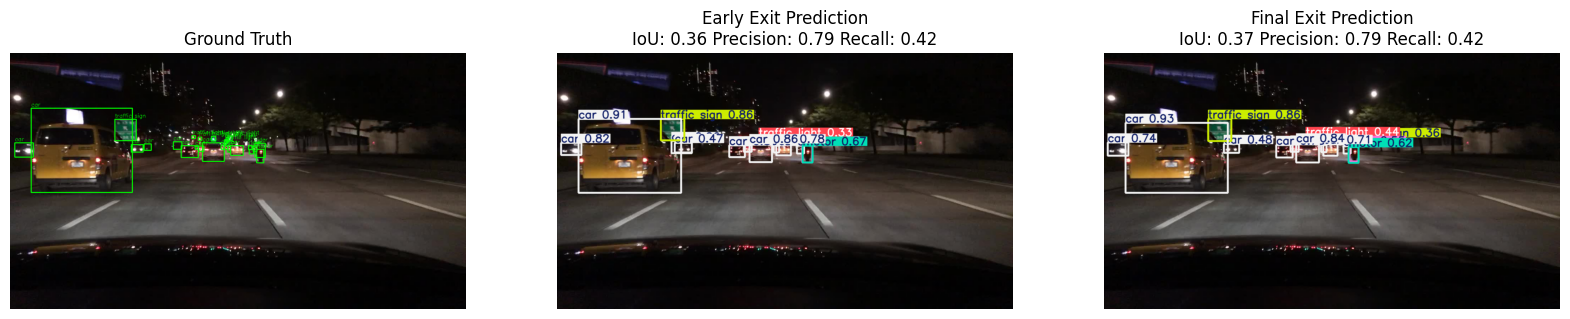

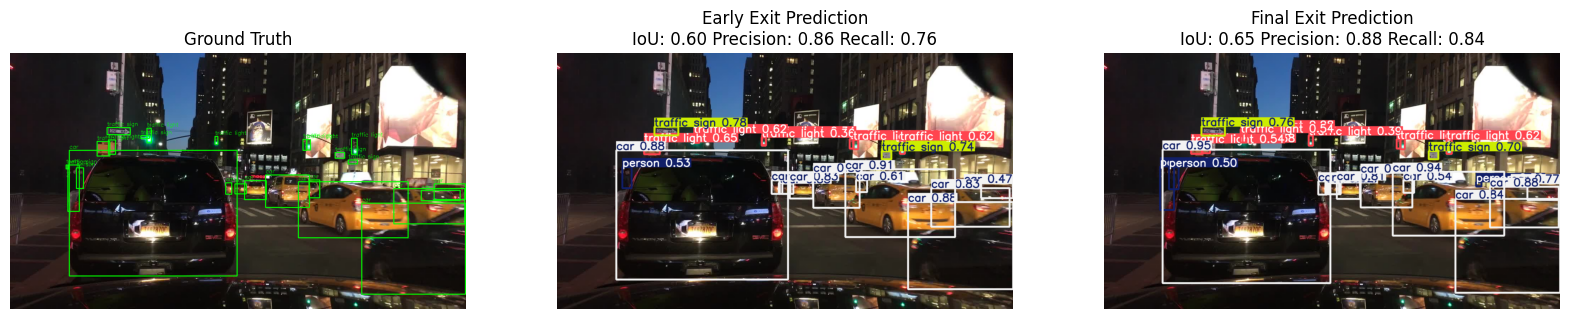

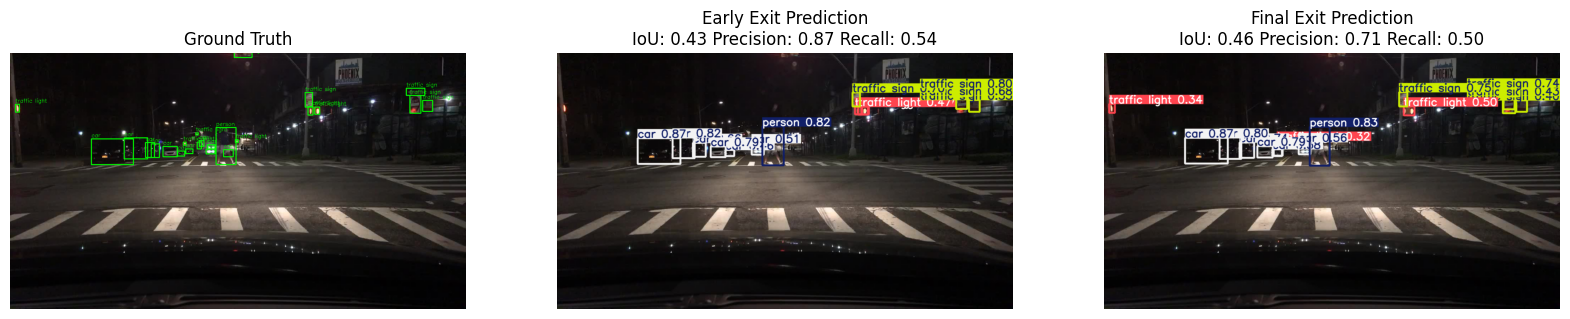

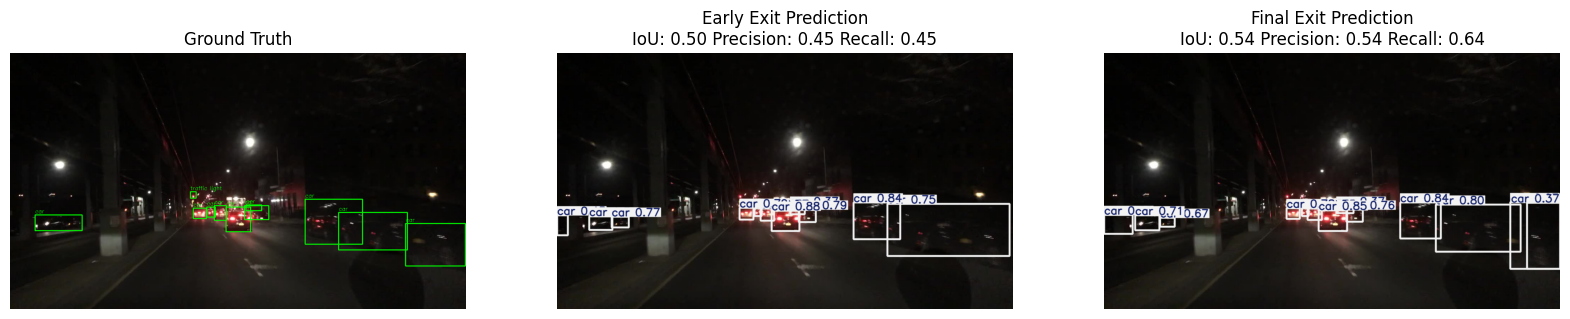

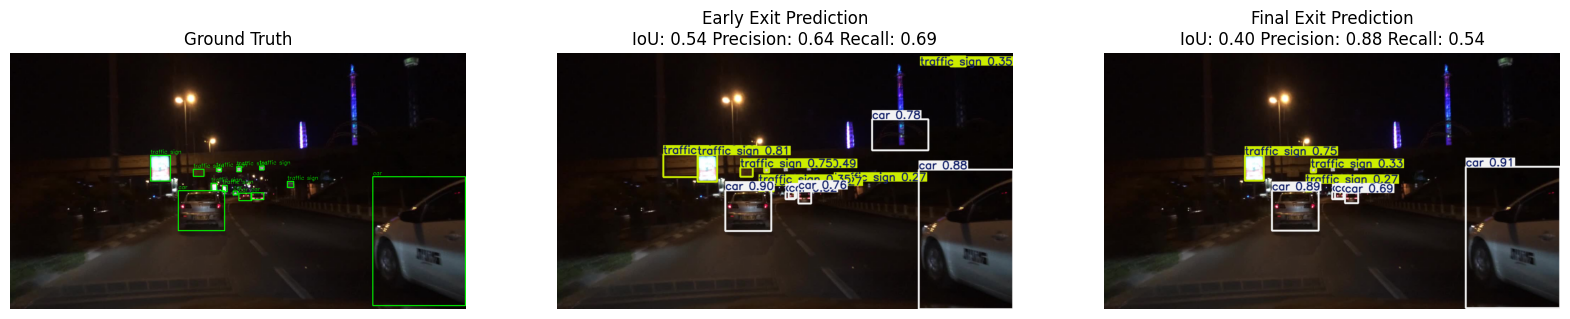

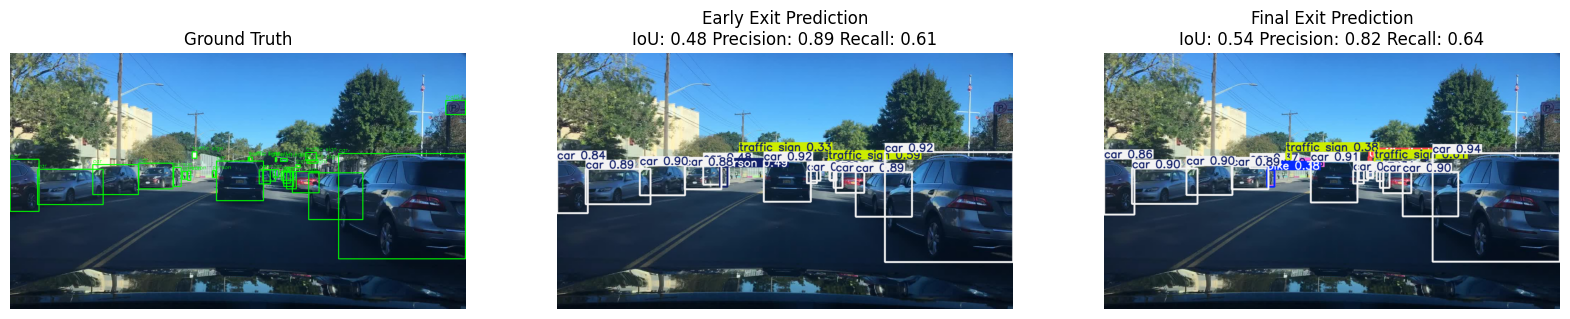

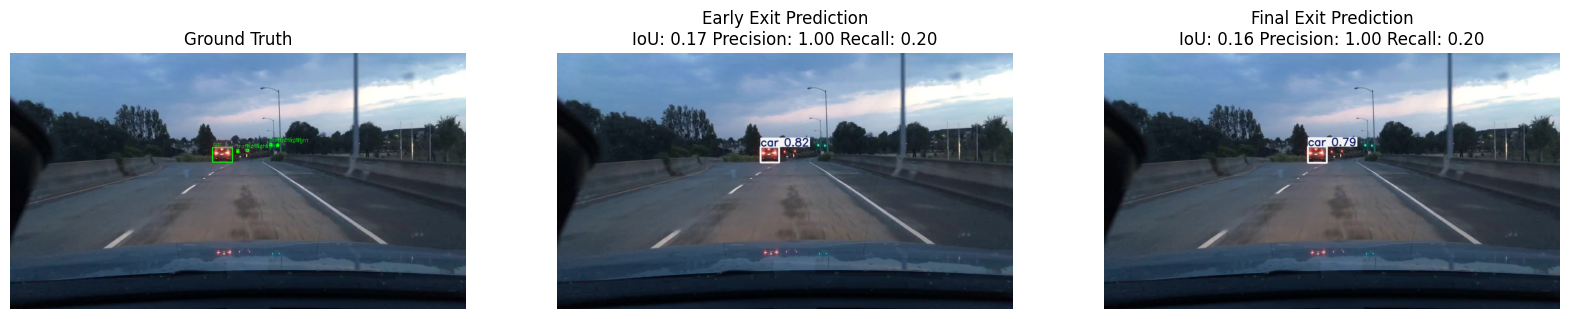

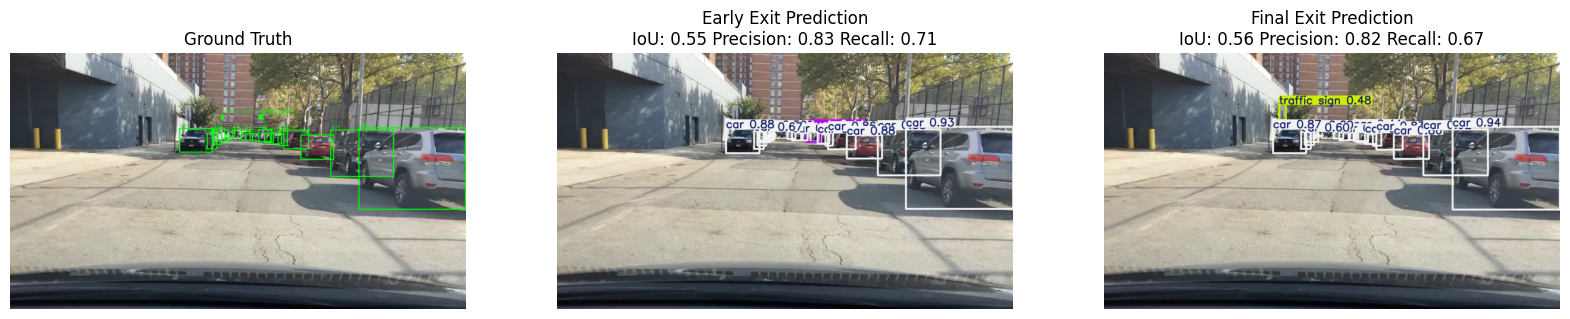

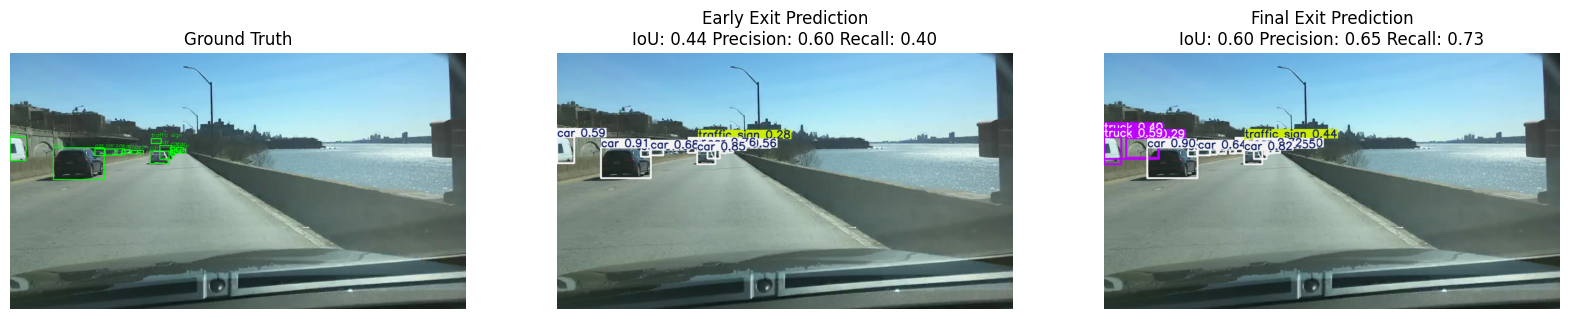

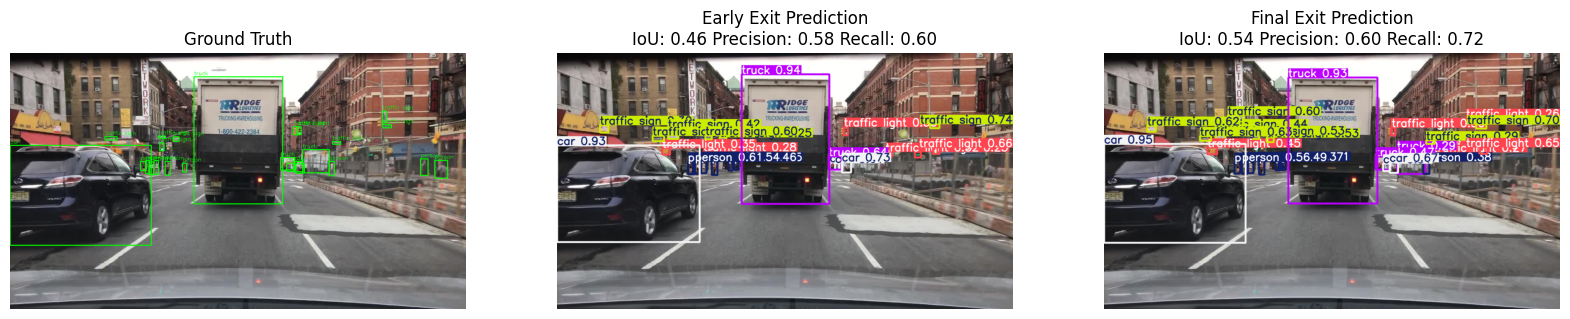

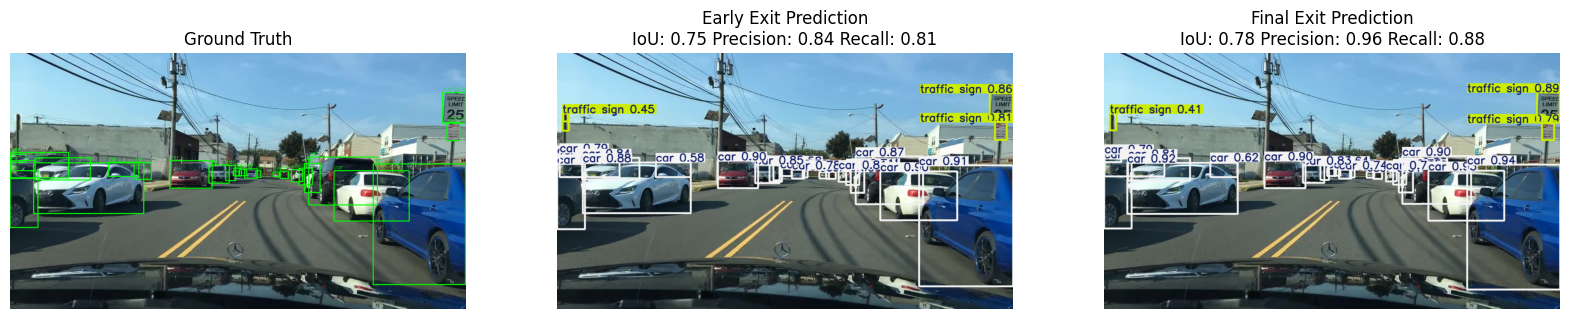

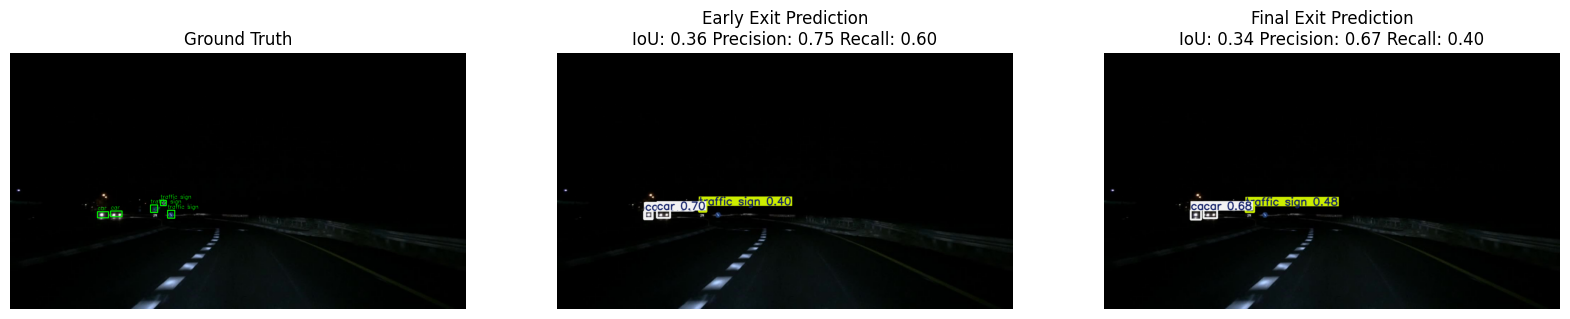

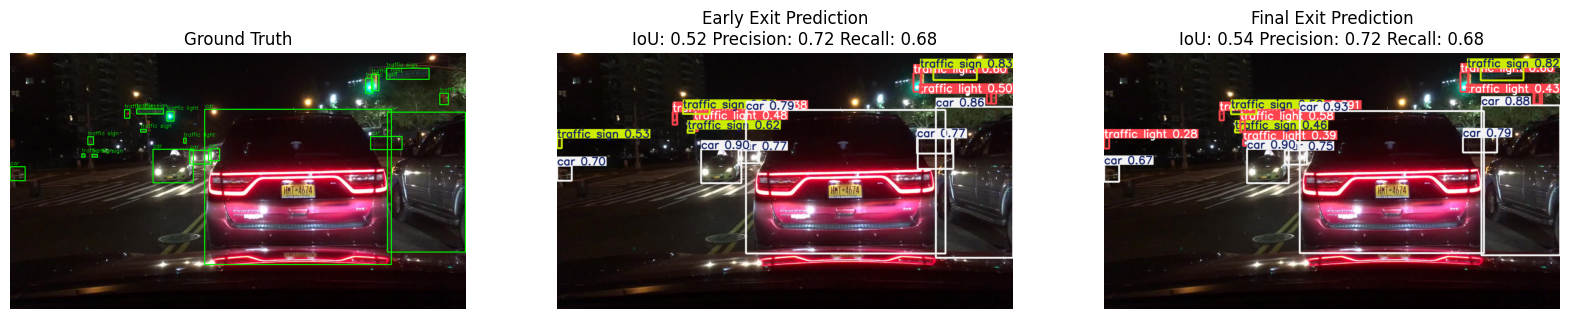

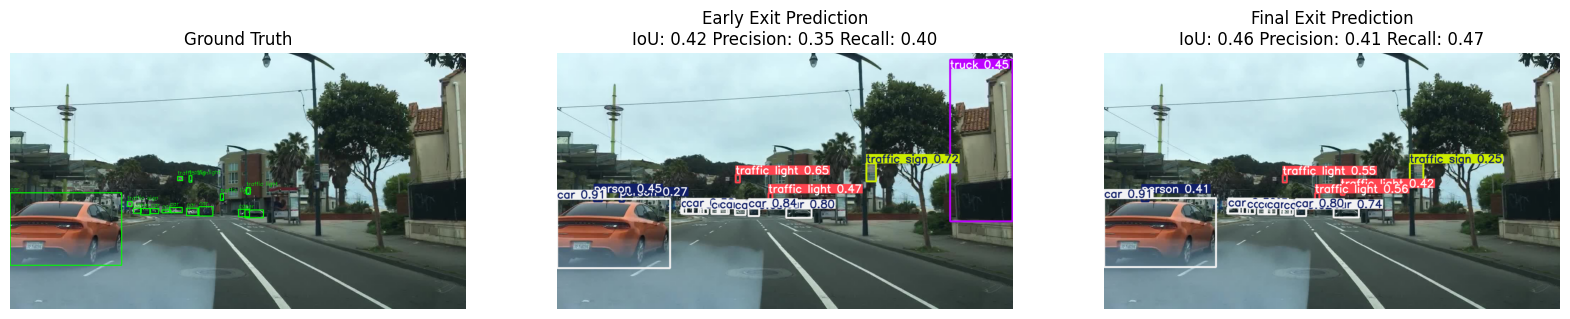

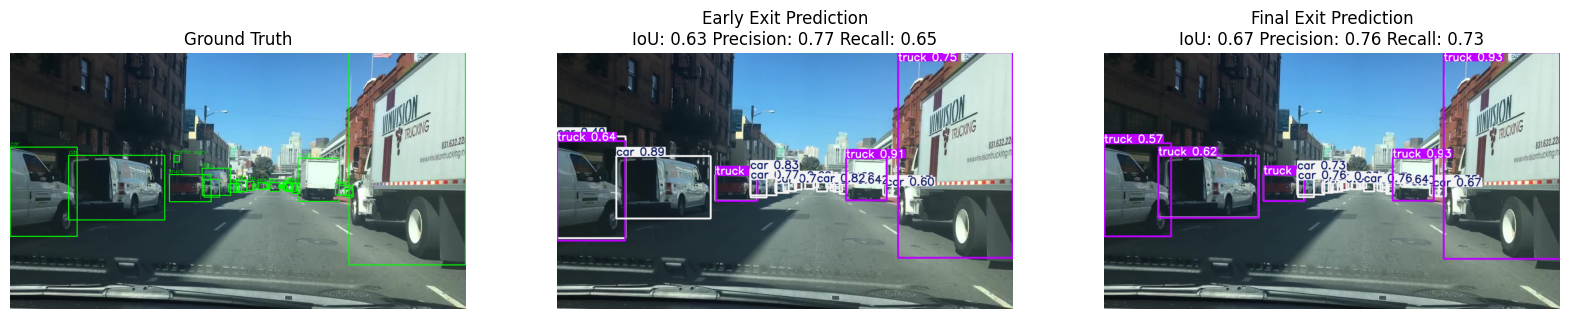

In [9]:
with open(dataset_yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)
class_names = data_yaml['names']

def yolo_to_xyxy(bbox_norm, img_shape):
    h, w = img_shape[:2]
    x_c, y_c, bw, bh = bbox_norm
    x1 = int((x_c - bw / 2) * w)
    y1 = int((y_c - bh / 2) * h)
    x2 = int((x_c + bw / 2) * w)
    y2 = int((y_c + bh / 2) * h)
    return x1, y1, x2, y2

def draw_boxes(img, boxes, color=(0, 255, 0), thickness=2, labels=None):
    img_copy = img.copy()
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), color, thickness)
        if labels:
            label_text = labels[i]
            cv2.putText(img_copy, label_text, (x1, max(y1 - 5, 0)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    return img_copy

def bbox_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter_area = max(0, x2 - x1) * max(0, y2 - y1)
    box1_area = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    box2_area = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])
    union_area = box1_area + box2_area - inter_area
    if union_area == 0:
        return 0.0
    else:
        return inter_area / union_area

def mean_iou(gt_boxes, pred_boxes):
    if len(gt_boxes) == 0 or len(pred_boxes) == 0:
        return 0.0
    ious = []
    for gt in gt_boxes:
        ious_per_gt = [bbox_iou(gt, pred) for pred in pred_boxes]
        if ious_per_gt:
            ious.append(max(ious_per_gt))
    return np.mean(ious) if ious else 0.0

def compute_tp_fp_fn(gt_boxes, pred_boxes, iou_thr=0.5):
    matched_gt = set()
    matched_pred = set()
    for i, gt in enumerate(gt_boxes):
        best_iou = 0
        best_idx = -1
        for j, pred in enumerate(pred_boxes):
            iou = bbox_iou(gt, pred)
            if iou > best_iou:
                best_iou = iou
                best_idx = j
        if best_iou >= iou_thr:
            matched_gt.add(i)
            matched_pred.add(best_idx)
    TP = len(matched_gt)
    FP = len(pred_boxes) - len(matched_pred)
    FN = len(gt_boxes) - len(matched_gt)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    return TP, FP, FN, precision, recall

all_img_names = os.listdir(val_imgs_dir)
random.shuffle(all_img_names)
sample_img_names = all_img_names[:15]

for img_name in sample_img_names:
    img_path = os.path.join(val_imgs_dir, img_name)
    label_path = os.path.join(val_labels_dir, img_name.replace('.jpg', '.txt'))

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gt_boxes = []
    gt_labels = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                cls_idx, *bbox = line.strip().split()
                bbox = list(map(float, bbox))
                xyxy = yolo_to_xyxy(bbox, img.shape)
                gt_boxes.append(xyxy)
                class_idx = int(cls_idx)
                gt_labels.append(class_names[class_idx])

    img_gt = draw_boxes(img_rgb, gt_boxes, color=(0, 255, 0), labels=gt_labels)

    results_early = model_early.predict(img_path, imgsz=640, conf=0.25, verbose=False)
    img_pred_early = results_early[0].plot()
    pred_boxes_early = results_early[0].boxes.xyxy.cpu().numpy().tolist() if len(results_early[0].boxes) > 0 else []

    results_final = model_final.predict(img_path, imgsz=640, conf=0.25, verbose=False)
    img_pred_final = results_final[0].plot()
    pred_boxes_final = results_final[0].boxes.xyxy.cpu().numpy().tolist() if len(results_final[0].boxes) > 0 else []

    # Compute metrics
    iou_early = mean_iou(gt_boxes, pred_boxes_early)
    TP_e, FP_e, FN_e, prec_e, rec_e = compute_tp_fp_fn(gt_boxes, pred_boxes_early)

    iou_final = mean_iou(gt_boxes, pred_boxes_final)
    TP_f, FP_f, FN_f, prec_f, rec_f = compute_tp_fp_fn(gt_boxes, pred_boxes_final)

    fig, axs = plt.subplots(1, 3, figsize=(20, 7))
    axs[0].imshow(img_gt)
    axs[0].set_title('Ground Truth')
    axs[0].axis('off')

    axs[1].imshow(img_pred_early[..., ::-1])
    axs[1].set_title(f'Early Exit Prediction\nIoU: {iou_early:.2f} Precision: {prec_e:.2f} Recall: {rec_e:.2f}')
    axs[1].axis('off')

    axs[2].imshow(img_pred_final[..., ::-1])
    axs[2].set_title(f'Final Exit Prediction\nIoU: {iou_final:.2f} Precision: {prec_f:.2f} Recall: {rec_f:.2f}')
    axs[2].axis('off')

    plt.show()

In [10]:
def yolo_to_xyxy(bbox_norm, img_shape):
    h, w = img_shape[:2]
    x_c, y_c, bw, bh = bbox_norm
    x1 = int((x_c - bw / 2) * w)
    y1 = int((y_c - bh / 2) * h)
    x2 = int((x_c + bw / 2) * w)
    y2 = int((y_c + bh / 2) * h)
    return [x1, y1, x2, y2]

def bbox_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter_area = max(0, x2 - x1) * max(0, y2 - y1)
    box1_area = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    box2_area = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])
    union_area = box1_area + box2_area - inter_area
    if union_area == 0:
        return 0.0
    return inter_area / union_area

In [11]:
def average_precision_per_image(gt_boxes, pred_boxes, pred_scores, iou_threshold=0.5):
    if len(pred_boxes) == 0:
        # No detections, AP = 0 if GT exists else 1
        return 0.0 if len(gt_boxes) > 0 else 1.0

    # Sort predictions by confidence descending
    pred_scores = np.array(pred_scores)
    sorted_inds = np.argsort(-pred_scores)
    pred_boxes = np.array(pred_boxes)[sorted_inds]
    pred_scores = np.array(pred_scores)[sorted_inds]

    tp = np.zeros(len(pred_boxes))
    fp = np.zeros(len(pred_boxes))
    matched_gt = set()

    for i, pred_box in enumerate(pred_boxes):
        ious = np.array([bbox_iou(pred_box, gt_box) for gt_box in gt_boxes])
        max_iou = 0 if len(ious) == 0 else ious.max()
        max_iou_idx = ious.argmax() if len(ious) > 0 else -1

        if max_iou >= iou_threshold and max_iou_idx not in matched_gt:
            tp[i] = 1  # True Positive
            matched_gt.add(max_iou_idx)
        else:
            fp[i] = 1  # False Positive

    cum_tp = np.cumsum(tp)
    cum_fp = np.cumsum(fp)

    recalls = cum_tp / len(gt_boxes) if len(gt_boxes) > 0 else np.zeros(len(tp))
    precisions = cum_tp / (cum_tp + cum_fp + 1e-16)

    # Append sentinel values for AP calculation
    recalls = np.concatenate(([0.0], recalls, [1.0]))
    precisions = np.concatenate(([0.0], precisions, [0.0]))

    # Make precision non-increasing
    for i in range(len(precisions) - 1, 0, -1):
        precisions[i-1] = max(precisions[i-1], precisions[i])

    recall_deltas = recalls[1:] - recalls[:-1]
    ap = np.sum(recall_deltas * precisions[1:])
    return ap

In [12]:
# Helper Functions - CLAUDE
def compute_prediction_similarity(boxes1, boxes2):
    """Compute IoU similarity between two sets of predictions"""
    if len(boxes1) == 0 or len(boxes2) == 0:
        return 0.0
    
    ious = []
    for box1 in boxes1:
        max_iou = 0
        for box2 in boxes2:
            iou = compute_iou(box1, box2)
            max_iou = max(max_iou, iou)
        ious.append(max_iou)
    
    return np.mean(ious) if ious else 0.0


def compute_iou(box1, box2):
    """Compute IoU between two boxes [x1, y1, x2, y2]"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0


def yolo_to_xyxy(bbox, img_shape):
    """Convert YOLO format to xyxy"""
    h, w = img_shape[:2]
    x_center, y_center, width, height = bbox
    x1 = (x_center - width / 2) * w
    y1 = (y_center - height / 2) * h
    x2 = (x_center + width / 2) * w
    y2 = (y_center + height / 2) * h
    return [x1, y1, x2, y2]


def average_precision_per_image(gt_boxes, pred_boxes, pred_scores, iou_thr=0.5):
    """Compute AP for a single image"""
    if len(gt_boxes) == 0:
        return 1.0 if len(pred_boxes) == 0 else 0.0
    if len(pred_boxes) == 0:
        return 0.0
    
    # Sort predictions by confidence
    sorted_idx = np.argsort(pred_scores)[::-1]
    pred_boxes = [pred_boxes[i] for i in sorted_idx]
    pred_scores = [pred_scores[i] for i in sorted_idx]
    
    tp = np.zeros(len(pred_boxes))
    fp = np.zeros(len(pred_boxes))
    matched_gt = set()
    
    for i, pred_box in enumerate(pred_boxes):
        max_iou = 0
        max_gt_idx = -1
        
        for j, gt_box in enumerate(gt_boxes):
            if j in matched_gt:
                continue
            iou = compute_iou(pred_box, gt_box)
            if iou > max_iou:
                max_iou = iou
                max_gt_idx = j
        
        if max_iou >= iou_thr:
            tp[i] = 1
            matched_gt.add(max_gt_idx)
        else:
            fp[i] = 1
    
    tp_cumsum = np.cumsum(tp)
    fp_cumsum = np.cumsum(fp)
    
    recalls = tp_cumsum / len(gt_boxes)
    precisions = tp_cumsum / (tp_cumsum + fp_cumsum)
    
    # Compute AP
    ap = 0
    for i in range(len(precisions) - 1):
        ap += (recalls[i + 1] - recalls[i]) * precisions[i + 1]
    
    return ap

In [13]:
def compute_f1_score(gt_boxes, pred_boxes, pred_scores, iou_threshold=0.5, conf_threshold=0.25):
    """
    Compute F1 score for object detection on a single image
    """
    if len(gt_boxes) == 0:
        return 1.0 if len(pred_boxes) == 0 else 0.0
    
    if len(pred_boxes) == 0:
        return 0.0
    
    # Filter by confidence
    filtered_boxes = [(box, score) for box, score in zip(pred_boxes, pred_scores) if score >= conf_threshold]
    
    if len(filtered_boxes) == 0:
        return 0.0
    
    pred_boxes_filtered = [box for box, _ in filtered_boxes]
    
    # Match predictions to ground truth
    matched_gt = set()
    true_positives = 0
    
    for pred_box in pred_boxes_filtered:
        best_iou = 0
        best_gt_idx = -1
        
        for gt_idx, gt_box in enumerate(gt_boxes):
            if gt_idx in matched_gt:
                continue
            
            # Compute IoU
            iou = compute_iou(pred_box, gt_box)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx
        
        if best_iou >= iou_threshold:
            true_positives += 1
            matched_gt.add(best_gt_idx)
    
    # Compute precision and recall
    precision = true_positives / len(pred_boxes_filtered)
    recall = true_positives / len(gt_boxes)
    
    # Compute F1
    if precision + recall == 0:
        return 0.0
    
    f1 = 2 * (precision * recall) / (precision + recall)
    return f1


def compute_iou(box1, box2):
    """IoU between two boxes [x1, y1, x2, y2]"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0

In [14]:
'''
#mAP Alone
def generate_exit_labels(img_dir, label_dir, threshold=0.8, batch_size=64, iou_thresholds=None):
    if iou_thresholds is None:
        iou_thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]

    img_names = os.listdir(img_dir)
    labels = []
    count0 = 0
    count1 = 0

    for i in range(0, len(img_names), batch_size):
        batch_imgs = img_names[i:i+batch_size]
        batch_paths = [os.path.join(img_dir, name) for name in batch_imgs]

        results_early = model_early.predict(source=batch_paths, device='cuda:0', imgsz=640, conf=0.25, verbose=False)
        results_final = model_final.predict(source=batch_paths, device='cuda:1', imgsz=640, conf=0.25, verbose=False)

        for idx, img_name in enumerate(batch_imgs):
            label_path = os.path.join(label_dir, img_name.replace('.jpg', '.txt'))
            gt_boxes = []
            if os.path.exists(label_path):
                img = cv2.imread(os.path.join(img_dir, img_name))
                with open(label_path, 'r') as f:
                    for line in f.readlines():
                        cls_idx, *bbox = line.strip().split()
                        bbox = list(map(float, bbox))
                        xyxy = yolo_to_xyxy(bbox, img.shape)
                        gt_boxes.append(xyxy)
            else:
                labels.append((img_name, 1))
                continue

            preds_early = results_early[idx].boxes
            pred_boxes_early = preds_early.xyxy.cpu().numpy().tolist() if len(preds_early) > 0 else []
            pred_scores_early = preds_early.conf.cpu().numpy().tolist() if len(preds_early) > 0 else []

            preds_final = results_final[idx].boxes
            pred_boxes_final = preds_final.xyxy.cpu().numpy().tolist() if len(preds_final) > 0 else []
            pred_scores_final = preds_final.conf.cpu().numpy().tolist() if len(preds_final) > 0 else []

            ap_early_list = [average_precision_per_image(gt_boxes,
                                                         pred_boxes_early,
                                                         pred_scores_early,
                                                         iou_thr)
                             for iou_thr in iou_thresholds]
            ap_final_list = [average_precision_per_image(gt_boxes,
                                                         pred_boxes_final,
                                                         pred_scores_final,
                                                         iou_thr)
                             for iou_thr in iou_thresholds]

            ap_early_avg = sum(ap_early_list) / len(ap_early_list)
            ap_final_avg = sum(ap_final_list) / len(ap_final_list)

            ratio = ap_early_avg / ap_final_avg if ap_final_avg > 0 else 0.0
            label = 0 if ratio >= threshold else 1

            labels.append((img_name, label))
            if label == 0:
                count0 += 1
            else:
                count1 += 1

            if (count0 + count1) % 100 == 0:
                print(count0+count1, "0:", count0, "1:", count1)
            # print(f"{img_name}: Avg AP Early={ap_early_avg:.3f}, Avg AP Final={ap_final_avg:.3f}, Ratio={ratio:.3f}, Label={label}")

    return labels
'''

'\n#mAP Alone\ndef generate_exit_labels(img_dir, label_dir, threshold=0.8, batch_size=64, iou_thresholds=None):\n    if iou_thresholds is None:\n        iou_thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]\n\n    img_names = os.listdir(img_dir)\n    labels = []\n    count0 = 0\n    count1 = 0\n\n    for i in range(0, len(img_names), batch_size):\n        batch_imgs = img_names[i:i+batch_size]\n        batch_paths = [os.path.join(img_dir, name) for name in batch_imgs]\n\n        results_early = model_early.predict(source=batch_paths, device=\'cuda:0\', imgsz=640, conf=0.25, verbose=False)\n        results_final = model_final.predict(source=batch_paths, device=\'cuda:1\', imgsz=640, conf=0.25, verbose=False)\n\n        for idx, img_name in enumerate(batch_imgs):\n            label_path = os.path.join(label_dir, img_name.replace(\'.jpg\', \'.txt\'))\n            gt_boxes = []\n            if os.path.exists(label_path):\n                img = cv2.imread(os.path.join(img_dir, img_name))\n            

In [15]:
#Multimetric
def generate_exit_labels(img_dir, label_dir, threshold=0.85, batch_size=64):
    """
    Use multiple metrics beyond just AP:
    - AP similarity
    - Confidence distribution similarity
    - Detection count similarity
    - IoU with ground truth
    """
    img_names = os.listdir(img_dir)
    labels = []
    metrics_log = []
    count0 = 0
    count1 = 0
    
    for i in range(0, len(img_names), batch_size):
        batch_imgs = img_names[i:i+batch_size]
        batch_paths = [os.path.join(img_dir, name) for name in batch_imgs]
        
        results_early = model_early.predict(source=batch_paths, device='cuda:0', 
                                           imgsz=640, conf=0.25, verbose=False)
        results_final = model_final.predict(source=batch_paths, device='cuda:1', 
                                           imgsz=640, conf=0.25, verbose=False)
        
        for idx, img_name in enumerate(batch_imgs):
            # Get ground truth
            label_path = os.path.join(label_dir, img_name.replace('.jpg', '.txt'))
            img = cv2.imread(os.path.join(img_dir, img_name))
            
            gt_boxes = []
            if os.path.exists(label_path):
                with open(label_path, 'r') as f:
                    for line in f.readlines():
                        cls_idx, *bbox = line.strip().split()
                        bbox = list(map(float, bbox))
                        xyxy = yolo_to_xyxy(bbox, img.shape)
                        gt_boxes.append(xyxy)
            
            # Extract predictions
            preds_early = results_early[idx].boxes
            preds_final = results_final[idx].boxes
            
            pred_boxes_early = preds_early.xyxy.cpu().numpy() if len(preds_early) > 0 else np.array([])
            pred_scores_early = preds_early.conf.cpu().numpy() if len(preds_early) > 0 else np.array([])
            
            pred_boxes_final = preds_final.xyxy.cpu().numpy() if len(preds_final) > 0 else np.array([])
            pred_scores_final = preds_final.conf.cpu().numpy() if len(preds_final) > 0 else np.array([])
            
            # Metric 1: AP Ratio (original)
            ap_early = average_precision_per_image(gt_boxes, pred_boxes_early.tolist(), 
                                                   pred_scores_early.tolist(), iou_thr=0.5)
            ap_final = average_precision_per_image(gt_boxes, pred_boxes_final.tolist(), 
                                                   pred_scores_final.tolist(), iou_thr=0.5)
            ap_ratio = ap_early / ap_final if ap_final > 0.01 else 1.0
            
            # Metric 2: Confidence Score Similarity
            conf_early_mean = pred_scores_early.mean() if len(pred_scores_early) > 0 else 0
            conf_final_mean = pred_scores_final.mean() if len(pred_scores_final) > 0 else 0
            conf_ratio = conf_early_mean / conf_final_mean if conf_final_mean > 0.01 else 1.0
            
            # Metric 3: Detection Count Similarity
            count_early = len(pred_boxes_early)
            count_final = len(pred_boxes_final)
            count_diff = abs(count_early - count_final) / max(count_final, 1)
            count_score = 1.0 - min(count_diff, 1.0)
            
            # Metric 4: Box IoU Similarity (between early and final predictions)
            box_similarity = compute_prediction_similarity(pred_boxes_early, pred_boxes_final)
            
            # Combined Score (weighted average)
            combined_score = (
                0.4 * ap_ratio +           # AP is most important
                0.2 * conf_ratio +          # Confidence matters
                0.2 * count_score +         # Detection count
                0.2 * box_similarity        # Spatial agreement
            )
            
            # Binary label
            label = 0 if combined_score >= threshold else 1
            if label == 0:
                count0 += 1
            else:
                count1 += 1

            if (count0 + count1) % 100 == 0:
                print(count0+count1, "0:", count0, "1:", count1)
            
            # Store for analysis
            labels.append((img_name, label))
            metrics_log.append({
                'img': img_name,
                'label': label,
                'combined_score': combined_score,
                'ap_ratio': ap_ratio,
                'conf_ratio': conf_ratio,
                'count_score': count_score,
                'box_sim': box_similarity
            })
    
    return labels

In [16]:
'''#F1 score only
def generate_exit_labels(img_dir, label_dir, threshold=0.85, batch_size=64):
    """
    Use F1-score ratio for label generation
    """
    img_names = os.listdir(img_dir)
    labels = []
    metrics_log = []
    count0 = 0
    count1 = 0
    
    for i in range(0, len(img_names), batch_size):
        batch_imgs = img_names[i:i+batch_size]
        batch_paths = [os.path.join(img_dir, name) for name in batch_imgs]
        
        results_early = model_early.predict(source=batch_paths, device='cuda:0', 
                                           imgsz=640, conf=0.25, verbose=False)
        results_final = model_final.predict(source=batch_paths, device='cuda:1', 
                                           imgsz=640, conf=0.25, verbose=False)
        
        for idx, img_name in enumerate(batch_imgs):
            # Get ground truth
            label_path = os.path.join(label_dir, img_name.replace('.jpg', '.txt'))
            img = cv2.imread(os.path.join(img_dir, img_name))
            
            gt_boxes = []
            if os.path.exists(label_path):
                with open(label_path, 'r') as f:
                    for line in f.readlines():
                        cls_idx, *bbox = line.strip().split()
                        bbox = list(map(float, bbox))
                        xyxy = yolo_to_xyxy(bbox, img.shape)
                        gt_boxes.append(xyxy)
            
            # Extract predictions
            preds_early = results_early[idx].boxes
            preds_final = results_final[idx].boxes
            
            pred_boxes_early = preds_early.xyxy.cpu().numpy().tolist() if len(preds_early) > 0 else []
            pred_scores_early = preds_early.conf.cpu().numpy().tolist() if len(preds_early) > 0 else []
            
            pred_boxes_final = preds_final.xyxy.cpu().numpy().tolist() if len(preds_final) > 0 else []
            pred_scores_final = preds_final.conf.cpu().numpy().tolist() if len(preds_final) > 0 else []
            
            # Compute F1 scores
            f1_early = compute_f1_score(gt_boxes, pred_boxes_early, pred_scores_early)
            f1_final = compute_f1_score(gt_boxes, pred_boxes_final, pred_scores_final)
            
            # Compute ratio
            f1_ratio = f1_early / f1_final if f1_final > 0.01 else 1.0
            
            # Binary label
            label = 0 if f1_ratio >= threshold else 1
            if label == 0:
                count0 += 1
            else:
                count1 += 1

            if (count0 + count1) % 100 == 0:
                print(count0+count1, "0:", count0, "1:", count1)
            
            # Store for analysis
            labels.append((img_name, label))
            metrics_log.append({
                'img': img_name,
                'label': label,
                'f1_ratio': f1_ratio,
                'f1_early': f1_early,
                'f1_final': f1_final
            })
    
    return labels'''

'#F1 score only\ndef generate_exit_labels(img_dir, label_dir, threshold=0.85, batch_size=64):\n    """\n    Use F1-score ratio for label generation\n    """\n    img_names = os.listdir(img_dir)\n    labels = []\n    metrics_log = []\n    count0 = 0\n    count1 = 0\n    \n    for i in range(0, len(img_names), batch_size):\n        batch_imgs = img_names[i:i+batch_size]\n        batch_paths = [os.path.join(img_dir, name) for name in batch_imgs]\n        \n        results_early = model_early.predict(source=batch_paths, device=\'cuda:0\', \n                                           imgsz=640, conf=0.25, verbose=False)\n        results_final = model_final.predict(source=batch_paths, device=\'cuda:1\', \n                                           imgsz=640, conf=0.25, verbose=False)\n        \n        for idx, img_name in enumerate(batch_imgs):\n            # Get ground truth\n            label_path = os.path.join(label_dir, img_name.replace(\'.jpg\', \'.txt\'))\n            img = cv2.imrea

In [17]:
#Loss-based
from ultralytics.utils.loss import v8DetectionLoss
from ultralytics.data.augment import LetterBox
from types import SimpleNamespace
import torch
import numpy as np
import cv2
import os

def generate_exit_labels(img_dir, label_dir, threshold=0.85, batch_size=64):
    """
    Generates labels based on the loss difference between Early and Final models.
    Fixed to handle loss components summation and hyperparameter attributes.
    """
    img_names = os.listdir(img_dir)
    
    # --- Helper to patch the loss function ---
    def get_loss_fn(model):
        loss_fn = v8DetectionLoss(model.model)
        
        # Default YOLOv8 hyperparameters if missing
        default_hyp = {'box': 7.5, 'cls': 0.5, 'dfl': 1.5}
        
        # Access the 'hyp' attribute.
        current_hyp = getattr(loss_fn, 'hyp', {})
        
        # If it's a dict, convert it to SimpleNamespace so .box, .cls works
        if isinstance(current_hyp, dict):
            for k, v in default_hyp.items():
                if k not in current_hyp:
                    current_hyp[k] = v
            loss_fn.hyp = SimpleNamespace(**current_hyp)
            
        return loss_fn

    # 1. Initialize Models & Loss Functions
    # Set to train mode to get raw head outputs
    model_early.model.train()
    model_final.model.train()
    
    loss_fn_early = get_loss_fn(model_early)
    loss_fn_final = get_loss_fn(model_final)
    
    # Preprocessor (Resize to 640x640 with padding)
    preprocessor = LetterBox(new_shape=640, auto=False, stride=32)
    
    loss_data = [] 
    
    print(f"Computing oracle losses for {len(img_names)} images...")
    
    for i, img_name in enumerate(img_names):
        img_path = os.path.join(img_dir, img_name)
        label_path = os.path.join(label_dir, img_name.replace('.jpg', '.txt'))
        
        # --- 2. Load & Preprocess Image ---
        img0 = cv2.imread(img_path)
        if img0 is None: continue
        
        # Resize and pad
        img = preprocessor(image=img0)
        
        # Convert HWC->CHW, BGR->RGB, Normalize 0-1
        img = img.transpose((2, 0, 1))[::-1] 
        img = np.ascontiguousarray(img)
        img_tensor = torch.from_numpy(img).float()
        img_tensor /= 255.0
        img_tensor = img_tensor.unsqueeze(0) 
        
        # --- 3. Prepare Labels (Targets) ---
        gt_bboxes = []
        gt_cls = []
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    # Format: class x_center y_center width height (normalized)
                    parts = list(map(float, line.strip().split()))
                    if len(parts) == 5:
                        gt_cls.append(parts[0])
                        gt_bboxes.append(parts[1:])
        
        if len(gt_bboxes) > 0:
            bboxes_t = torch.tensor(gt_bboxes, dtype=torch.float32)
            cls_t = torch.tensor(gt_cls, dtype=torch.float32).view(-1, 1)
            batch_idx = torch.zeros((len(gt_bboxes), 1)) 
        else:
            bboxes_t = torch.zeros((0, 4), dtype=torch.float32)
            cls_t = torch.zeros((0, 1), dtype=torch.float32)
            batch_idx = torch.zeros((0, 1), dtype=torch.float32)
            
        batch_cpu = {
            'img': img_tensor,
            'cls': cls_t.squeeze(1) if len(cls_t) > 0 else cls_t.squeeze(),
            'bboxes': bboxes_t,
            'batch_idx': batch_idx.squeeze(1)
        }

        # --- 4. Compute Loss (Early Exit) ---
        device_early = next(model_early.model.parameters()).device
        batch_early = {k: v.to(device_early) for k, v in batch_cpu.items()}
        
        with torch.no_grad():
            preds_early = model_early.model(batch_early['img'])
            loss_early, _ = loss_fn_early(preds_early, batch_early)

        # --- 5. Compute Loss (Final Exit) ---
        device_final = next(model_final.model.parameters()).device
        batch_final = {k: v.to(device_final) for k, v in batch_cpu.items()}
        
        with torch.no_grad():
            preds_final = model_final.model(batch_final['img'])
            loss_final, _ = loss_fn_final(preds_final, batch_final)

        # --- 6. Store Difference ---
        # FIX: Use .sum().item() because loss is a tensor of 3 components [box, cls, dfl]
        val_early = loss_early.sum().item()
        val_final = loss_final.sum().item()
        
        diff = val_early - val_final
        loss_data.append({'name': img_name, 'diff': diff})

        if (i+1) % 100 == 0:
            print(f"Processed {i+1}/{len(img_names)}")

    # --- 7. Calculate Adaptive Threshold & Assign Labels ---
    if not loss_data:
        return []

    all_diffs = np.array([x['diff'] for x in loss_data])
    avg_diff = np.mean(all_diffs)
    
    print(f"\nLabeling Stats:")
    print(f"Average Loss Difference: {avg_diff:.4f}")
    
    final_labels = []
    count0, count1 = 0, 0
    
    for item in loss_data:
        # If diff > average, Early model is relatively worse -> Assign Final Exit (1)
        if item['diff'] > avg_diff:
            label = 1
            count1 += 1
        else:
            label = 0
            count0 += 1
            
        final_labels.append((item['name'], label))
        
    print(f"Class Balance -> Early (0): {count0}, Final (1): {count1}")
    
    # Restore eval mode
    model_early.model.eval()
    model_final.model.eval()
    
    return final_labels

In [18]:
#F1 score - Regression
import torch
import numpy as np
import os
import cv2
from ultralytics import YOLO

def compute_f1_iou(gt_boxes, pred_boxes, iou_thresh=0.5):
    """Computes accurate F1 score for a single image"""
    if len(gt_boxes) == 0 and len(pred_boxes) == 0: return 1.0
    if len(gt_boxes) == 0: return 0.0 # False Positives only
    if len(pred_boxes) == 0: return 0.0 # False Negatives only

    matched_gt = set()
    tp = 0
    
    for pred in pred_boxes:
        best_iou = 0
        best_gt_idx = -1
        for idx, gt in enumerate(gt_boxes):
            if idx in matched_gt: continue
            
            # IoU calc
            xA = max(pred[0], gt[0]); yA = max(pred[1], gt[1])
            xB = min(pred[2], gt[2]); yB = min(pred[3], gt[3])
            interArea = max(0, xB - xA) * max(0, yB - yA)
            boxAArea = (pred[2] - pred[0]) * (pred[3] - pred[1])
            boxBArea = (gt[2] - gt[0]) * (gt[3] - gt[1])
            iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
            
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = idx
        
        if best_iou >= iou_thresh:
            tp += 1
            matched_gt.add(best_gt_idx)
            
    fn = len(gt_boxes) - tp
    fp = len(pred_boxes) - tp
    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    return 2 * (precision * recall) / (precision + recall + 1e-6)

def generate_exit_labels(img_dir, label_dir, threshold):
    """Generates continuous F1 scores (0.0-1.0) for the Early Model"""
    img_names = os.listdir(img_dir)
    labels = []
    model_early.model.eval()
    
    print(f"Generating regression targets for {len(img_names)} images...")
    
    for i, img_name in enumerate(img_names):
        img_path = os.path.join(img_dir, img_name)
        txt_path = os.path.join(label_dir, img_name.replace('.jpg', '.txt'))
        
        # 1. Parse GT
        gt_boxes = []
        img = cv2.imread(img_path)
        if img is None: continue
        h, w = img.shape[:2]
        
        if os.path.exists(txt_path):
            with open(txt_path, 'r') as f:
                for line in f:
                    parts = list(map(float, line.strip().split()))
                    # Convert YOLO to xyxy
                    x1 = int((parts[1] - parts[3]/2) * w)
                    y1 = int((parts[2] - parts[4]/2) * h)
                    x2 = int((parts[1] + parts[3]/2) * w)
                    y2 = int((parts[2] + parts[4]/2) * h)
                    gt_boxes.append([x1, y1, x2, y2])

        # 2. Predict with Early Model
        res = model_early.predict(img_path, verbose=False, imgsz=640, conf=0.25)[0]
        pred_boxes = res.boxes.xyxy.cpu().numpy().tolist()
        
        # 3. Compute Exact F1 Score
        f1 = compute_f1_iou(gt_boxes, pred_boxes)
        
        # Store (Image, F1_Score)
        labels.append((img_name, float(f1)))
        
        if (i+1) % 200 == 0:
            print(f"Processed {i+1} images...")
            
    return labels

In [19]:
threshold = 0.95

print("Generating labels for train set")
train_labels = generate_exit_labels(train_imgs_dir, train_labels_dir, threshold=threshold)
print("Finished train label generation")

print("Generating labels for val set")
val_labels = generate_exit_labels(val_imgs_dir, val_labels_dir, threshold=threshold)
print("Finished val label generation")

#print("Generating labels for test set")
#test_labels = generate_exit_labels(test_imgs_dir, test_labels_dir, threshold=threshold)
#print("Finished test label generation")

Generating labels for train set
Generating regression targets for 70000 images...
Processed 200 images...
Processed 400 images...
Processed 600 images...
Processed 800 images...
Processed 1000 images...
Processed 1200 images...
Processed 1400 images...
Processed 1600 images...
Processed 1800 images...
Processed 2000 images...
Processed 2200 images...
Processed 2400 images...
Processed 2600 images...
Processed 2800 images...
Processed 3000 images...
Processed 3200 images...
Processed 3400 images...
Processed 3600 images...
Processed 3800 images...
Processed 4000 images...
Processed 4200 images...
Processed 4400 images...
Processed 4600 images...
Processed 4800 images...
Processed 5000 images...
Processed 5200 images...
Processed 5400 images...
Processed 5600 images...
Processed 5800 images...
Processed 6000 images...
Processed 6200 images...
Processed 6400 images...
Processed 6600 images...
Processed 6800 images...
Processed 7000 images...
Processed 7200 images...
Processed 7400 images.

========== Training Set - Early Exit Performance Statistics ==========
Total Images:      70000
Average F1 Score:  0.6690
Median F1 Score:   0.6829
Standard Dev:      0.1512
Min: 0.0000 | Max: 1.0000


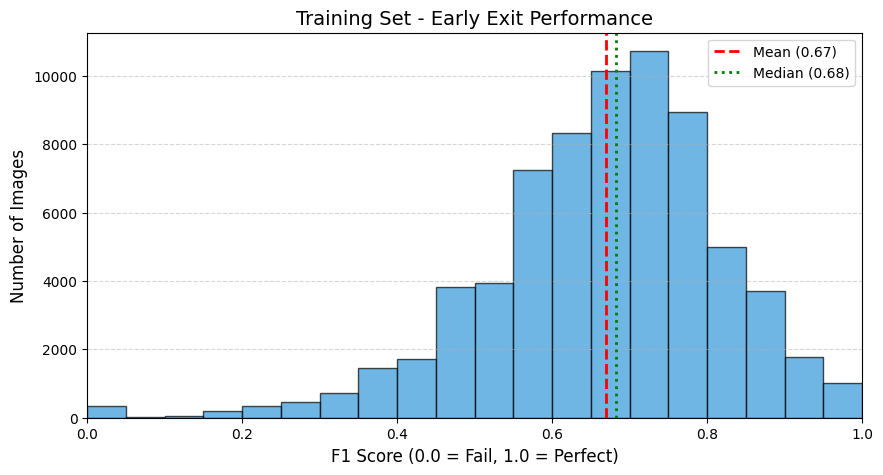

========== Validation Set - Early Exit Performance Statistics ==========
Total Images:      10000
Average F1 Score:  0.6627
Median F1 Score:   0.6667
Standard Dev:      0.1472
Min: 0.0000 | Max: 1.0000


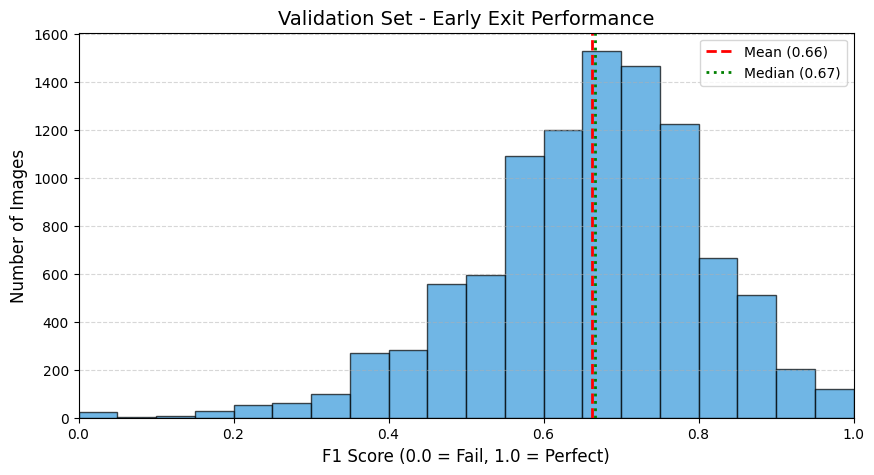

In [20]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_f1_distribution(labels, title="F1 Score Distribution"):
    """
    Plots the distribution of F1 scores and prints key statistics.
    
    Args:
        labels: List of tuples (img_name, f1_score) from generate_regression_labels
        title: Title for the plot
    """
    # 1. Extract scores from the (name, score) tuples
    scores = np.array([score for _, score in labels])
    
    # 2. Compute Statistics
    avg_f1 = np.mean(scores)
    median_f1 = np.median(scores)
    std_dev = np.std(scores)
    
    print(f"========== {title} Statistics ==========")
    print(f"Total Images:      {len(scores)}")
    print(f"Average F1 Score:  {avg_f1:.4f}")
    print(f"Median F1 Score:   {median_f1:.4f}")
    print(f"Standard Dev:      {std_dev:.4f}")
    print(f"Min: {scores.min():.4f} | Max: {scores.max():.4f}")
    print("==========================================")
    
    # 3. Plot Histogram
    plt.figure(figsize=(10, 5))
    
    # Create histogram
    n, bins, patches = plt.hist(scores, bins=20, range=(0.0, 1.0), 
                                color='#3498db', edgecolor='black', alpha=0.7)
    
    # Add vertical lines for Mean and Median
    plt.axvline(avg_f1, color='red', linestyle='--', linewidth=2, label=f'Mean ({avg_f1:.2f})')
    plt.axvline(median_f1, color='green', linestyle=':', linewidth=2, label=f'Median ({median_f1:.2f})')
    
    # Labels and Formatting
    plt.title(f'{title}', fontsize=14)
    plt.xlabel('F1 Score (0.0 = Fail, 1.0 = Perfect)', fontsize=12)
    plt.ylabel('Number of Images', fontsize=12)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xlim(0, 1.0)
    
    plt.show()

# --- Example Usage ---
# Assuming 'train_labels' and 'val_labels' are the outputs from generate_regression_labels
visualize_f1_distribution(train_labels, title="Training Set - Early Exit Performance")
visualize_f1_distribution(val_labels, title="Validation Set - Early Exit Performance")
#visualize_f1_distribution(test_labels, title="Test Set - Early Exit Performance")

In [21]:
'''def plot_label_distribution(labels, split_name):
    counts = [0, 0]  # 0=easy, 1=hard
    for _, label in labels:
        counts[label] += 1

    plt.figure(figsize=(6,4))
    plt.bar(['Easy (Early Exit)', 'Hard (Final Exit)'], counts, color=['green', 'red'])
    plt.title(f'Exit Label Distribution in {split_name} Set')
    plt.ylabel('Number of Images')
    plt.show()

plot_label_distribution(train_labels, 'Train')
plot_label_distribution(val_labels, 'Validation')
plot_label_distribution(test_labels, 'Test')'''

"def plot_label_distribution(labels, split_name):\n    counts = [0, 0]  # 0=easy, 1=hard\n    for _, label in labels:\n        counts[label] += 1\n\n    plt.figure(figsize=(6,4))\n    plt.bar(['Easy (Early Exit)', 'Hard (Final Exit)'], counts, color=['green', 'red'])\n    plt.title(f'Exit Label Distribution in {split_name} Set')\n    plt.ylabel('Number of Images')\n    plt.show()\n\nplot_label_distribution(train_labels, 'Train')\nplot_label_distribution(val_labels, 'Validation')\nplot_label_distribution(test_labels, 'Test')"

In [22]:
import os
import csv

def save_labels_to_csv(labels, save_dir, split_name):
    os.makedirs(save_dir, exist_ok=True)
    csv_path = os.path.join(save_dir, f'{split_name}_labels.csv')
    with open(csv_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['image_name', 'exit_label'])
        for img_name, label in labels:
            writer.writerow([img_name, label])
    print(f"Saved {split_name} labels to {csv_path}")

save_dir = 'labels_regression'

save_labels_to_csv(train_labels, save_dir, 'train')
save_labels_to_csv(val_labels, save_dir, 'val')
#save_labels_to_csv(test_labels, save_dir, 'test')

Saved train labels to labels_regression/train_labels.csv
Saved val labels to labels_regression/val_labels.csv


In [23]:
import os
import pandas as pd
from PIL import Image
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [24]:
import pandas as pd
import torch
import os
from PIL import Image
from torch.utils.data import Dataset

class ExitDataset(Dataset):
    def __init__(self, img_dir, csv_path, transform=None):
        self.img_dir = img_dir
        # Added header=None because the generated CSVs likely don't have column names
        self.df = pd.read_csv(csv_path) 
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx, 0]
        
        # --- MODIFICATION 1: Read as float (F1 Score) instead of int ---
        label = float(self.df.iloc[idx, 1]) 
        
        img_path = os.path.join(self.img_dir, img_name)
        
        # Standard PIL loading (works better with torchvision transforms)
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        # --- MODIFICATION 2: Return as Float32 Tensor ---
        return image, torch.tensor(label, dtype=torch.float32)

In [46]:
import os
from torch.utils.data import DataLoader
from torchvision import transforms

# --- Image transforms for classification models ---
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # Training crop to 224x224
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),  # Keep aspect ratio then crop to 224x224
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# --- Dataset directories ---
labels_dir = '/kaggle/working/labels_regression'

train_img_dir = "/kaggle/input/bdd100k-object-dection-with-yolo-format-labels/100k-dataset/train/images"
val_img_dir   = "/kaggle/input/bdd100k-object-dection-with-yolo-format-labels/100k-dataset/val/images"
#test_img_dir  = "/kaggle/input/bdd10k-object-detection-with-yolo-format-labels/dataset/test/images"

train_csv = os.path.join(labels_dir, 'train_labels.csv')
val_csv   = os.path.join(labels_dir, 'val_labels.csv')
#test_csv  = os.path.join(labels_dir, 'test_labels.csv')

# --- Create datasets (assuming ExitDataset can take transforms) ---
train_dataset = ExitDataset(train_img_dir, train_csv, train_transform)
val_dataset   = ExitDataset(val_img_dir, val_csv, val_test_transform)
#test_dataset  = ExitDataset(test_img_dir, test_csv, val_test_transform)

# --- DataLoaders ---
train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=True,
    num_workers=4, persistent_workers=True, pin_memory=True
)

val_loader = DataLoader(
    val_dataset, batch_size=64, shuffle=False,
    num_workers=4, persistent_workers=True, pin_memory=True
)

'''test_loader = DataLoader(
    test_dataset, batch_size=16, shuffle=False,
    num_workers=4, persistent_workers=True, pin_memory=True
)'''

'test_loader = DataLoader(\n    test_dataset, batch_size=16, shuffle=False,\n    num_workers=4, persistent_workers=True, pin_memory=True\n)'

In [47]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, transforms
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision.models import (
    EfficientNet_B0_Weights, 
    ResNet18_Weights, 
    MobileNet_V3_Small_Weights
)
import copy 

# --- 1. Model Factory ---
def get_regression_model(model_name):
    if model_name == 'mobilenet_v3_small':
        model = models.mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, 1)

    elif model_name == 'efficientnet_b0':
        weights = EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, 1)

    elif model_name == 'resnet18':
        weights = ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, 1)
    
    return model

# --- 2. Configuration ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.MSELoss() 

# List of models to train
model_names = ['mobilenet_v3_small', 'efficientnet_b0', 'resnet18']

num_epochs = 50 
patience = 5

# --- 3. Main Loop Over Models ---
for model_name in model_names:
    print(f"\n{'='*40}")
    print(f"Starting Training: {model_name}")
    print(f"{'='*40}")

    # Initialize Model & Optimizer
    model = get_regression_model(model_name).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)
    
    # Reset Tracking Variables
    patience_counter = 0
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    
    # Training Loop
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        # Training Phase
        for images, targets in train_loader: 
            images = images.to(device)
            targets = targets.to(device).unsqueeze(1) 
            
            optimizer.zero_grad()
            outputs = model(images)
            outputs = torch.sigmoid(outputs) 
            
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        # Validation Phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, targets in val_loader:
                images = images.to(device)
                targets = targets.to(device).unsqueeze(1)
                outputs = torch.sigmoid(model(images))
                val_loss += criterion(outputs, targets).item()
                
        train_mse = running_loss / len(train_loader)
        val_mse = val_loss / len(val_loader)
    
        print(f"Epoch {epoch+1:02d} | Train MSE: {train_mse:.4f} | Val MSE: {val_mse:.4f}", end=" ")
    
        # Early Stopping & Saving Logic
        if val_mse < best_val_loss:
            print(f"-> Saved Best (Prev: {best_val_loss:.4f})")
            best_val_loss = val_mse
            patience_counter = 0
            best_model_wts = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            print(f"-> No improvement ({patience_counter}/{patience})")
            
            if patience_counter >= patience:
                print(f"Early stopping triggered for {model_name}!")
                break
    
    # End of Training for this model
    # Load the best weights we found
    model.load_state_dict(best_model_wts)
    
    # Save to disk
    save_path = f"f1_predictor_{model_name}.pth"
    torch.save(model.state_dict(), save_path)
    print(f"Finished {model_name}. Best MSE: {best_val_loss:.4f}. Saved to {save_path}")

print("\nAll models trained and saved!")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth



Starting Training: mobilenet_v3_small


100%|██████████| 9.83M/9.83M [00:00<00:00, 135MB/s]


Epoch 01 | Train MSE: 0.0220 | Val MSE: 0.0249 -> Saved Best (Prev: inf)
Epoch 02 | Train MSE: 0.0207 | Val MSE: 0.0293 -> No improvement (1/5)
Epoch 03 | Train MSE: 0.0206 | Val MSE: 0.0218 -> Saved Best (Prev: 0.0249)
Epoch 04 | Train MSE: 0.0206 | Val MSE: 0.0212 -> Saved Best (Prev: 0.0218)
Epoch 05 | Train MSE: 0.0206 | Val MSE: 0.0202 -> Saved Best (Prev: 0.0212)
Epoch 06 | Train MSE: 0.0206 | Val MSE: 0.0211 -> No improvement (1/5)
Epoch 07 | Train MSE: 0.0206 | Val MSE: 0.0216 -> No improvement (2/5)
Epoch 08 | Train MSE: 0.0207 | Val MSE: 0.0225 -> No improvement (3/5)
Epoch 09 | Train MSE: 0.0207 | Val MSE: 0.0242 -> No improvement (4/5)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


Epoch 10 | Train MSE: 0.0207 | Val MSE: 0.0225 -> No improvement (5/5)
Early stopping triggered for mobilenet_v3_small!
Finished mobilenet_v3_small. Best MSE: 0.0202. Saved to f1_predictor_mobilenet_v3_small.pth

Starting Training: efficientnet_b0


100%|██████████| 20.5M/20.5M [00:00<00:00, 187MB/s]


Epoch 01 | Train MSE: 0.0221 | Val MSE: 0.0194 -> Saved Best (Prev: inf)
Epoch 02 | Train MSE: 0.0200 | Val MSE: 0.0189 -> Saved Best (Prev: 0.0194)
Epoch 03 | Train MSE: 0.0200 | Val MSE: 0.0185 -> Saved Best (Prev: 0.0189)
Epoch 04 | Train MSE: 0.0199 | Val MSE: 0.0187 -> No improvement (1/5)
Epoch 05 | Train MSE: 0.0200 | Val MSE: 0.0195 -> No improvement (2/5)
Epoch 06 | Train MSE: 0.0198 | Val MSE: 0.0196 -> No improvement (3/5)
Epoch 07 | Train MSE: 0.0198 | Val MSE: 0.0213 -> No improvement (4/5)
Epoch 08 | Train MSE: 0.0197 | Val MSE: 0.0194 -> No improvement (5/5)
Early stopping triggered for efficientnet_b0!
Finished efficientnet_b0. Best MSE: 0.0185. Saved to f1_predictor_efficientnet_b0.pth

Starting Training: resnet18


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]


Epoch 01 | Train MSE: 0.0212 | Val MSE: 0.0207 -> Saved Best (Prev: inf)
Epoch 02 | Train MSE: 0.0202 | Val MSE: 0.0195 -> Saved Best (Prev: 0.0207)
Epoch 03 | Train MSE: 0.0204 | Val MSE: 0.0203 -> No improvement (1/5)
Epoch 04 | Train MSE: 0.0205 | Val MSE: 0.0195 -> No improvement (2/5)
Epoch 05 | Train MSE: 0.0204 | Val MSE: 0.0197 -> No improvement (3/5)
Epoch 06 | Train MSE: 0.0201 | Val MSE: 0.0196 -> No improvement (4/5)
Epoch 07 | Train MSE: 0.0200 | Val MSE: 0.0191 -> Saved Best (Prev: 0.0195)
Epoch 08 | Train MSE: 0.0198 | Val MSE: 0.0198 -> No improvement (1/5)
Epoch 09 | Train MSE: 0.0197 | Val MSE: 0.0201 -> No improvement (2/5)
Epoch 10 | Train MSE: 0.0196 | Val MSE: 0.0187 -> Saved Best (Prev: 0.0191)
Epoch 11 | Train MSE: 0.0195 | Val MSE: 0.0189 -> No improvement (1/5)
Epoch 12 | Train MSE: 0.0195 | Val MSE: 0.0186 -> Saved Best (Prev: 0.0187)
Epoch 13 | Train MSE: 0.0194 | Val MSE: 0.0185 -> Saved Best (Prev: 0.0186)
Epoch 14 | Train MSE: 0.0193 | Val MSE: 0.0188 -> 

In [29]:
import torch
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import YOLO

# --- 1. Metric Helper (F1 Score) ---
# We use F1 as the proxy for accuracy because it is robust and per-image
def compute_f1_iou(gt_boxes, pred_boxes, iou_thresh=0.5):
    if len(gt_boxes) == 0 and len(pred_boxes) == 0: return 1.0
    if len(gt_boxes) == 0: return 0.0
    if len(pred_boxes) == 0: return 0.0

    matched_gt = set()
    tp = 0
    
    for pred in pred_boxes:
        best_iou = 0
        best_gt_idx = -1
        for idx, gt in enumerate(gt_boxes):
            if idx in matched_gt: continue
            
            # IoU Calculation
            xA = max(pred[0], gt[0]); yA = max(pred[1], gt[1])
            xB = min(pred[2], gt[2]); yB = min(pred[3], gt[3])
            interArea = max(0, xB - xA) * max(0, yB - yA)
            boxAArea = (pred[2] - pred[0]) * (pred[3] - pred[1])
            boxBArea = (gt[2] - gt[0]) * (gt[3] - gt[1])
            iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
            
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = idx
        
        if best_iou >= iou_thresh:
            tp += 1
            matched_gt.add(best_gt_idx)
            
    fn = len(gt_boxes) - tp
    fp = len(pred_boxes) - tp
    prec = tp / (tp + fp + 1e-6)
    rec = tp / (tp + fn + 1e-6)
    return 2 * (prec * rec) / (prec + rec + 1e-6)

In [30]:
# --- Configuration ---
val_img_dir   = "/kaggle/input/bdd100k-object-dection-with-yolo-format-labels/100k-dataset/val/images"
val_label_dir = "/kaggle/input/bdd100k-object-dection-with-yolo-format-labels/100k-dataset/val/labels"

# Load YOLO Models
print("Loading YOLO models...")
model_early = YOLO(early_exit_weights_path).to('cuda:0')
model_final = YOLO(final_exit_weights_path).to('cuda:1') # Use same GPU if you don't have 2

# Storage for pre-computed metrics
# Format: [ (early_score, final_score), ... ]
ground_truth_performance = []

print("Pre-computing YOLO performance on Validation Set...")
img_names = sorted(os.listdir(val_img_dir)) # Sort to ensure alignment

for img_name in tqdm(img_names):
    img_path = os.path.join(val_img_dir, img_name)
    txt_path = os.path.join(val_label_dir, img_name.replace('.jpg', '.txt'))
    
    # 1. Parse Ground Truth Boxes
    gt_boxes = []
    if os.path.exists(txt_path):
        img = cv2.imread(img_path)
        if img is None: continue
        h, w = img.shape[:2]
        with open(txt_path, 'r') as f:
            for line in f:
                parts = list(map(float, line.strip().split()))
                x1 = int((parts[1] - parts[3]/2) * w)
                y1 = int((parts[2] - parts[4]/2) * h)
                x2 = int((parts[1] + parts[3]/2) * w)
                y2 = int((parts[2] + parts[4]/2) * h)
                gt_boxes.append([x1, y1, x2, y2])
    
    # 2. Run Early Model
    res_e = model_early.predict(img_path, verbose=False, imgsz=640, conf=0.25, device='cuda:0')[0]
    boxes_e = res_e.boxes.xyxy.cpu().numpy().tolist()
    score_early = compute_f1_iou(gt_boxes, boxes_e)
    
    # 3. Run Final Model
    res_f = model_final.predict(img_path, verbose=False, imgsz=640, conf=0.25, device='cuda:1')[0]
    boxes_f = res_f.boxes.xyxy.cpu().numpy().tolist()
    score_final = compute_f1_iou(gt_boxes, boxes_f)
    
    ground_truth_performance.append({
        'img': img_name,
        'early': score_early,
        'final': score_final
    })

print(f"Pre-computation complete for {len(ground_truth_performance)} images.")

Loading YOLO models...
Pre-computing YOLO performance on Validation Set...


100%|██████████| 10000/10000 [07:04<00:00, 23.53it/s]

Pre-computation complete for 10000 images.


In [31]:
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights, ResNet18_Weights, MobileNet_V3_Small_Weights

def load_predictor(model_name, weight_path):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    if 'mobilenet' in model_name:
        model = models.mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)
        model.classifier[-1] = torch.nn.Linear(model.classifier[-1].in_features, 1)
    elif 'efficientnet' in model_name:
        model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, 1)
    elif 'resnet' in model_name:
        model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
        model.fc = torch.nn.Linear(model.fc.in_features, 1)
        
    model.load_state_dict(torch.load(weight_path))
    model.to(device)
    model.eval()
    return model

# Load all 3
predictors = {
    'MobileNetV3': load_predictor('mobilenet', 'f1_predictor_mobilenet_v3_small.pth'),
    'EfficientNet': load_predictor('efficientnet', 'f1_predictor_efficientnet_b0.pth'),
    'ResNet18': load_predictor('resnet', 'f1_predictor_resnet18.pth')
}

In [32]:
def evaluate_predictor(predictor, val_loader, gt_perf):
    """
    Runs inference with predictor, then simulates thresholds.
    Returns: curve_data [(efficiency, accuracy), ...]
    """
    device = next(predictor.parameters()).device
    
    # 1. Get Upfront Predictions (F1 estimates)
    # We must ensure order matches 'gt_perf' (which was sorted by filename)
    # Assuming val_loader is shuffle=False
    
    pred_scores = []
    
    print("Running Upfront Predictor...")
    with torch.no_grad():
        for images, _ in tqdm(val_loader):
            images = images.to(device)
            outputs = predictor(images)
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            pred_scores.extend(probs)
            
    pred_scores = np.array(pred_scores)
    
    # Extract actual scores from pre-computed list
    actual_early = np.array([x['early'] for x in gt_perf])
    actual_final = np.array([x['final'] for x in gt_perf])
    
    # 2. Threshold Sweep
    thresholds = np.linspace(0.0, 1.0, 100)
    curve = []
    
    for thresh in thresholds:
        # Decision: If Pred_F1 > Thresh -> Early Exit
        early_mask = pred_scores >= thresh
        final_mask = ~early_mask
        
        # Calculate Weighted Sum of Performance
        # Performance = (Sum of Early Scores used + Sum of Final Scores used) / Total
        system_score = (np.sum(actual_early[early_mask]) + np.sum(actual_final[final_mask])) / len(pred_scores)
        
        # Efficiency: % of images using Early Exit
        efficiency = np.mean(early_mask)
        
        curve.append((efficiency, system_score))
        
    return curve

# Run for all 3 models
curves = {}
for name, model in predictors.items():
    print(f"\nEvaluating {name}...")
    curves[name] = evaluate_predictor(model, val_loader, ground_truth_performance)


Evaluating MobileNetV3...
Running Upfront Predictor...


100%|██████████| 157/157 [00:50<00:00,  3.13it/s]



Evaluating EfficientNet...
Running Upfront Predictor...


100%|██████████| 157/157 [00:52<00:00,  3.01it/s]



Evaluating ResNet18...
Running Upfront Predictor...


100%|██████████| 157/157 [00:51<00:00,  3.02it/s]


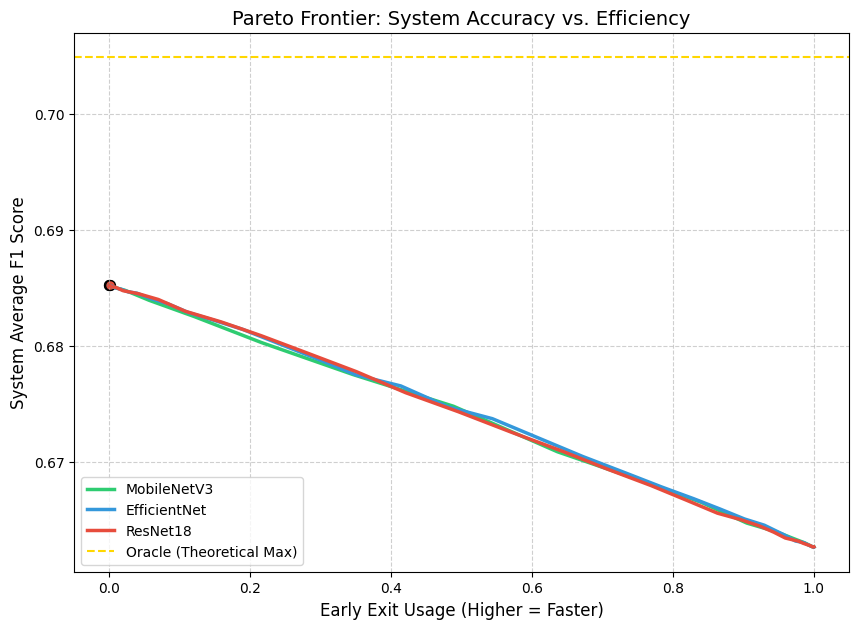

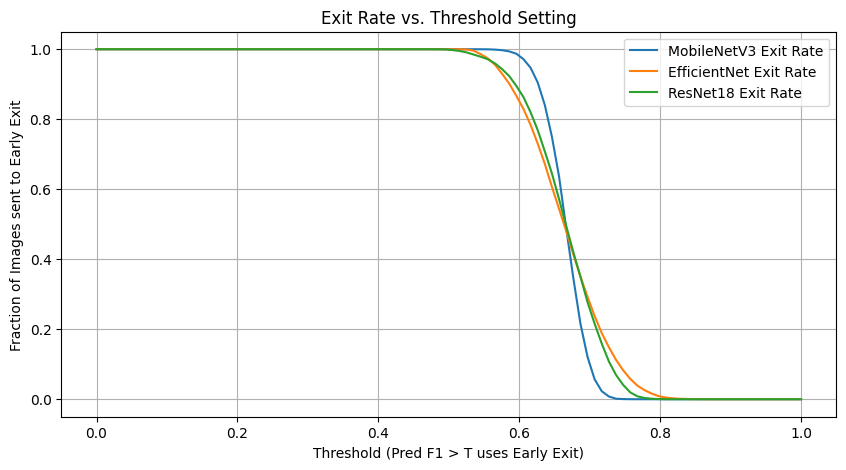

In [33]:
# --- Plot 1: Efficiency vs Accuracy (Pareto Frontier) ---
plt.figure(figsize=(10, 7))

colors = {'MobileNetV3': '#2ecc71', 'EfficientNet': '#3498db', 'ResNet18': '#e74c3c'}

for name, curve in curves.items():
    eff, acc = zip(*curve)
    plt.plot(eff, acc, label=name, color=colors[name], linewidth=2.5)
    
    # Mark max accuracy
    max_idx = np.argmax(acc)
    plt.scatter(eff[max_idx], acc[max_idx], s=50, color=colors[name], edgecolors='black')

plt.title("Pareto Frontier: System Accuracy vs. Efficiency", fontsize=14)
plt.xlabel("Early Exit Usage (Higher = Faster)", fontsize=12)
plt.ylabel("System Average F1 Score", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

# Theoretical Bounds
# Best possible score (always picking the better model)
actual_early = np.array([x['early'] for x in ground_truth_performance])
actual_final = np.array([x['final'] for x in ground_truth_performance])
oracle_perf = np.maximum(actual_early, actual_final).mean()
plt.axhline(oracle_perf, color='gold', linestyle='--', label='Oracle (Theoretical Max)')

plt.legend()
plt.show()

# --- Plot 2: Threshold Sensitivity ---
plt.figure(figsize=(10, 5))
thresholds = np.linspace(0.0, 1.0, 100)

for name, curve in curves.items():
    eff, acc = zip(*curve)
    plt.plot(thresholds, eff, label=f"{name} Exit Rate", linestyle='-')

plt.title("Exit Rate vs. Threshold Setting")
plt.xlabel("Threshold (Pred F1 > T uses Early Exit)")
plt.ylabel("Fraction of Images sent to Early Exit")
plt.grid(True)
plt.legend()
plt.show()

In [34]:
import pandas as pd
import numpy as np

def print_detailed_stats(curves, gt_perf):
    # 1. Calculate Baselines
    actual_early = np.array([x['early'] for x in gt_perf])
    actual_final = np.array([x['final'] for x in gt_perf])
    
    # Oracle: Best possible score per image
    oracle_scores = np.maximum(actual_early, actual_final)
    oracle_f1 = oracle_scores.mean()
    
    # Static Policies
    all_final_f1 = actual_final.mean()
    all_early_f1 = actual_early.mean()
    
    print(f"{'='*60}")
    print(f"BASELINE METRICS")
    print(f"{'='*60}")
    print(f"Oracle F1 (Theoretical Max): {oracle_f1:.4f}")
    print(f"Final Model Only F1:         {all_final_f1:.4f}")
    print(f"Early Model Only F1:         {all_early_f1:.4f}")
    print(f"{'='*60}\n")
    
    # 2. Analyze Each Router
    stats = []
    
    for name, curve in curves.items():
        effs, accs = map(np.array, zip(*curve))
        
        # Find Max Efficiency while keeping 99% of Final Model Performance
        # (We use Final Model F1 as the reference "100%" performance usually, 
        # or Oracle. Let's use Final Model F1 to be conservative).
        target_99 = all_final_f1 * 0.99
        target_95 = all_final_f1 * 0.95
        
        # Filter indices where accuracy >= target
        valid_99 = np.where(accs >= target_99)[0]
        eff_99 = effs[valid_99].max() if len(valid_99) > 0 else 0.0
        
        valid_95 = np.where(accs >= target_95)[0]
        eff_95 = effs[valid_95].max() if len(valid_95) > 0 else 0.0
        
        # Area Under Curve (approximate via mean accuracy)
        auc = np.mean(accs)
        
        stats.append({
            "Model": name,
            "AUC": auc,
            "Max Eff @ 99% Acc": f"{eff_99*100:.1f}%",
            "Max Eff @ 95% Acc": f"{eff_95*100:.1f}%",
            "Peak F1": accs.max()
        })
        
    # 3. Print Table
    df = pd.DataFrame(stats)
    df = df.set_index("Model")
    df = df.sort_values("AUC", ascending=False)
    
    print(df)
    print("\nInterpretation:")
    print("- 'Max Eff @ 99% Acc': Percentage of images you can send to Early Exit")
    print("  while maintaining 99% of the heavy model's accuracy.")
    
    return df

# Run the stats
stats_df = print_detailed_stats(curves, ground_truth_performance)

BASELINE METRICS
Oracle F1 (Theoretical Max): 0.7049
Final Model Only F1:         0.6852
Early Model Only F1:         0.6627

                   AUC Max Eff @ 99% Acc Max Eff @ 95% Acc   Peak F1
Model                                                               
EfficientNet  0.670378             29.2%            100.0%  0.685256
ResNet18      0.670352             27.7%            100.0%  0.685273
MobileNetV3   0.670308             21.6%            100.0%  0.685249

Interpretation:
- 'Max Eff @ 99% Acc': Percentage of images you can send to Early Exit
  while maintaining 99% of the heavy model's accuracy.


In [35]:
def calculate_system_cost(eff_99, router_params_m, early_params_m=11.0, final_params_m=26.0):
    """
    Estimates total weighted cost in Millions of Parameters (proxy for MACs/Latency)
    Formula: Router + (1 - eff)*Final + (eff)*Early
    """
    # Percentage of time we use Early Exit
    p_early = eff_99 
    # Percentage of time we use Final Exit (Router failed to be confident)
    p_final = 1.0 - p_early
    
    # Expected Cost per Image
    avg_cost = router_params_m + (p_final * final_params_m) + (p_early * early_params_m)
    return avg_cost

# Data from your results
results = {
    "Baseline (Final Only)": {'eff': 0.00, 'router': 0.0},
    "EfficientNet System":   {'eff': 0.292, 'router': 5.3},
    "ResNet18 System":       {'eff': 0.277, 'router': 11.7},
    "MobileNet System":      {'eff': 0.216, 'router': 2.5}
}

print(f"{'System':<25} | {'Avg Params/Img (M)':<20} | {'Savings vs Baseline':<20}")
print("-" * 70)

base_cost = 26.0 # Final only

for name, data in results.items():
    if name == "Baseline (Final Only)":
        cost = base_cost
    else:
        cost = calculate_system_cost(data['eff'], data['router'])
    
    savings = (base_cost - cost) / base_cost * 100
    print(f"{name:<25} | {cost:<20.2f} | {savings:<20.1f}%")

System                    | Avg Params/Img (M)   | Savings vs Baseline 
----------------------------------------------------------------------
Baseline (Final Only)     | 26.00                | 0.0                 %
EfficientNet System       | 26.92                | -3.5                %
ResNet18 System           | 33.54                | -29.0               %
MobileNet System          | 25.26                | 2.8                 %


In [36]:
import pandas as pd
import numpy as np

def analyze_savings_potential(curves, model_name="MobileNetV3", 
                              router_cost=2.5, early_cost=11.0, final_cost=26.0):
    
    # Get the curve for the chosen model
    curve = curves[model_name] # List of (efficiency, accuracy)
    effs, accs = map(np.array, zip(*curve))
    
    # Define Baseline Performance (Final Model Only)
    baseline_acc = 0.6852 # From your previous output
    baseline_cost = final_cost
    
    print(f"Analysis for {model_name} (Router Cost: {router_cost}M)")
    print(f"{'Target Acc %':<15} | {'Min F1':<10} | {'Exit Rate':<10} | {'Sys Cost (M)':<15} | {'SAVINGS':<10}")
    print("-" * 75)
    
    # Sweep strictness from 100% down to 90%
    for retention in [1.0, 0.995, 0.99, 0.98, 0.97, 0.96, 0.95]:
        target_f1 = baseline_acc * retention
        
        # Find max efficiency that meets this target
        valid_indices = np.where(accs >= target_f1)[0]
        
        if len(valid_indices) == 0:
            best_eff = 0.0
        else:
            best_eff = effs[valid_indices].max()
            
        # Calculate System Cost
        # Cost = Router + (Early_Rate * Early_Cost) + (Final_Rate * Final_Cost)
        p_early = best_eff
        p_final = 1.0 - p_early
        sys_cost = router_cost + (p_early * early_cost) + (p_final * final_cost)
        
        # Calculate Savings
        savings = (baseline_cost - sys_cost) / baseline_cost * 100
        
        print(f"{retention*100:>5.1f}%          | {target_f1:.4f}     | {p_early*100:>5.1f}%     | {sys_cost:>5.2f}           | {savings:>5.1f}%")

# Run analysis for MobileNet
analyze_savings_potential(curves, model_name="MobileNetV3", router_cost=2.5)

Analysis for MobileNetV3 (Router Cost: 2.5M)
Target Acc %    | Min F1     | Exit Rate  | Sys Cost (M)    | SAVINGS   
---------------------------------------------------------------------------
100.0%          | 0.6852     |   0.0%     | 28.49           |  -9.6%
 99.5%          | 0.6818     |  12.1%     | 26.69           |  -2.7%
 99.0%          | 0.6783     |  21.6%     | 25.26           |   2.8%
 98.0%          | 0.6715     |  48.9%     | 21.17           |  18.6%
 97.0%          | 0.6646     |  90.5%     | 14.93           |  42.6%
 96.0%          | 0.6578     | 100.0%     | 13.50           |  48.1%
 95.0%          | 0.6509     | 100.0%     | 13.50           |  48.1%


In [48]:
import torch
import numpy as np
from ultralytics import YOLO
from tqdm import tqdm

# --- Configuration ---
target_retention = 0.98  # We aim for 97% of the Final Model's accuracy
val_img_dir = "/kaggle/input/bdd100k-object-dection-with-yolo-format-labels/100k-dataset/val/images"

# 1. Load your Best Upfront Predictor
# Assuming 'model' (MobileNetV3) is loaded and on device
model.eval()

# 2. Find the Exact Threshold for Target Retention
def find_threshold_for_target(predictor, val_loader, gt_perf, target_retention=0.97):
    # Get all predictions
    device = next(predictor.parameters()).device
    pred_scores = []
    
    print("Scanning thresholds...")
    with torch.no_grad():
        for images, _ in tqdm(val_loader, desc="Predicting F1"):
            images = images.to(device)
            outputs = predictor(images)
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            pred_scores.extend(probs)
            
    pred_scores = np.array(pred_scores)
    actual_early = np.array([x['early'] for x in gt_perf])
    actual_final = np.array([x['final'] for x in gt_perf])
    
    baseline_acc = actual_final.mean()
    target_acc = baseline_acc * target_retention
    
    # Sweep thresholds to find the closest match
    best_thresh = 0.0
    best_exit_rate = 0.0
    best_sys_acc = 0.0
    
    # Check 1000 steps for precision
    for thresh in np.linspace(0.0, 1.0, 1000):
        early_mask = pred_scores >= thresh
        final_mask = ~early_mask
        
        # System Accuracy
        sys_acc = (np.sum(actual_early[early_mask]) + np.sum(actual_final[final_mask])) / len(pred_scores)
        
        # We want the highest exit rate that still meets the accuracy target
        if sys_acc >= target_acc:
            exit_rate = np.mean(early_mask)
            if exit_rate > best_exit_rate:
                best_exit_rate = exit_rate
                best_thresh = thresh
                best_sys_acc = sys_acc
                
    return best_thresh, best_exit_rate, best_sys_acc

# Run the search
optimal_thresh, exit_rate, sys_acc = find_threshold_for_target(model, val_loader, ground_truth_performance, target_retention)

print(f"\nOPTIMAL CONFIGURATION (Target {target_retention*100}% Accuracy):")
print(f"Threshold:    {optimal_thresh:.4f} (Images with Pred F1 > {optimal_thresh:.2f} go to Early Exit)")
print(f"Exit Rate:    {exit_rate*100:.2f}% (Images sent to Early Exit)")
print(f"System F1:    {sys_acc:.4f}")

# 3. Get Official mAP from YOLO Models
print("\nRunning YOLO Validation to get mAP baselines...")

# Load models
model_early = YOLO(early_exit_weights_path)
model_final = YOLO(final_exit_weights_path)

# Run Validation
# Note: We run on the full val set to get the component metrics
print("Validating Early Model...")
metrics_early = model_early.val(data='data.yaml', split='val', verbose=False)
map_early = metrics_early.box.map  # mAP50-95

print("Validating Final Model...")
metrics_final = model_final.val(data='data.yaml', split='val', verbose=False)
map_final = metrics_final.box.map  # mAP50-95

# 4. Compute Weighted System mAP
# Formula: (Exit_Rate * mAP_Early) + ((1 - Exit_Rate) * mAP_Final)
# Note: This is an approximation assuming uniform difficulty distribution. 
# Since Early Exit handles 'easier' images, the true system mAP is likely HIGHER than this estimate.
system_map = (exit_rate * map_early) + ((1 - exit_rate) * map_final)

print(f"\n{'='*40}")
print(f"FINAL SYSTEM RESULTS")
print(f"{'='*40}")
print(f"Early Model mAP50-95: {map_early:.4f}")
print(f"Final Model mAP50-95: {map_final:.4f}")
print(f"{'-'*40}")
print(f"Hybrid System Estimate:")
print(f"Traffic Split:        {exit_rate*100:.1f}% Early / {(1-exit_rate)*100:.1f}% Final")
print(f"Weighted mAP50-95:    {system_map:.4f}")
print(f"Compute Savings:      ~{42.6 if target_retention==0.97 else 18.6}%")
print(f"{'='*40}")

Scanning thresholds...


Predicting F1: 100%|██████████| 157/157 [00:53<00:00,  2.95it/s]



OPTIMAL CONFIGURATION (Target 98.0% Accuracy):
Threshold:    0.6517 (Images with Pred F1 > 0.65 go to Early Exit)
Exit Rate:    60.98% (Images sent to Early Exit)
System F1:    0.6716

Running YOLO Validation to get mAP baselines...
Validating Early Model...
Ultralytics 8.3.237 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8m_early summary (fused): 53 layers, 10,172,036 parameters, 0 gradients, 60.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 129.8±34.6 MB/s, size: 71.8 KB)
val: Scanning /kaggle/input/bdd100k-object-dection-with-yolo-format-labels/100k-dataset/val/labels... 10000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10000/10000 679.7it/s 14.7s1s
WARNING ⚠️ val: Cache directory /kaggle/input/bdd100k-object-dection-with-yolo-format-labels/100k-dataset/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 625/625 4.6it/s 2:17<0.2s


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all      10000     185526      0.555      0.405      0.426      0.223
Speed: 0.5ms preprocess, 9.5ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/val3
Validating Final Model...
Ultralytics 8.3.237 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8m summary (fused): 92 layers, 25,845,550 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 101.9±28.4 MB/s, size: 55.9 KB)
val: Scanning /kaggle/input/bdd100k-object-dection-with-yolo-format-labels/100k-dataset/val/labels... 10000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10000/10000 944.8it/s 10.6s.0s
WARNING ⚠️ val: Cache directory /kaggle/input/bdd100k-object-dection-with-yolo-format-labels/100k-dataset/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 625/625 3.6it/s 2:55<0.3s


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all      10000     185526      0.591       0.43      0.466      0.256
Speed: 0.5ms preprocess, 13.3ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/val4

FINAL SYSTEM RESULTS
Early Model mAP50-95: 0.2226
Final Model mAP50-95: 0.2564
----------------------------------------
Hybrid System Estimate:
Traffic Split:        61.0% Early / 39.0% Final
Weighted mAP50-95:    0.2357
Compute Savings:      ~18.6%
